In [1]:
# importing the necessary libraries
from mlxtend.plotting import plot_decision_regions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [3]:
# Loading the dataset
heart_data = pd.read_csv('heart_cleveland_upload.csv')

# Print the first 5 rows of the dataframe
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [4]:
# Create a list of the columns for X and for Y
X_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
          'restecg', 'thalach', 'exang', 'oldpeak',
          'slope', 'ca', 'thal']
y_col = 'condition'

print("Features:", X_cols)
print("Target:", y_col)

Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target: condition


In [5]:
## info() method gives information about the data types, columns,
## null value counts, memory usage etc
heart_data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [6]:
## basic statistic details about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [7]:
## creating the transpose of the description of the Dataframe
heart_data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,2.158249,0.964859,0.0,2.0,2.0,3.0,3.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


In [9]:
heart_data_copy = heart_data.copy(deep=True)

# replacing the 0 values with Nan
heart_data_copy[['trestbps', 'chol', 'thalach', 'oldpeak']] = \
    heart_data_copy[['trestbps', 'chol', 'thalach', 'oldpeak']].replace(0, np.nan)

## showing the count of Nans
print(heart_data_copy.isnull().sum())

age           0
sex           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak      96
slope         0
ca            0
thal          0
condition     0
dtype: int64


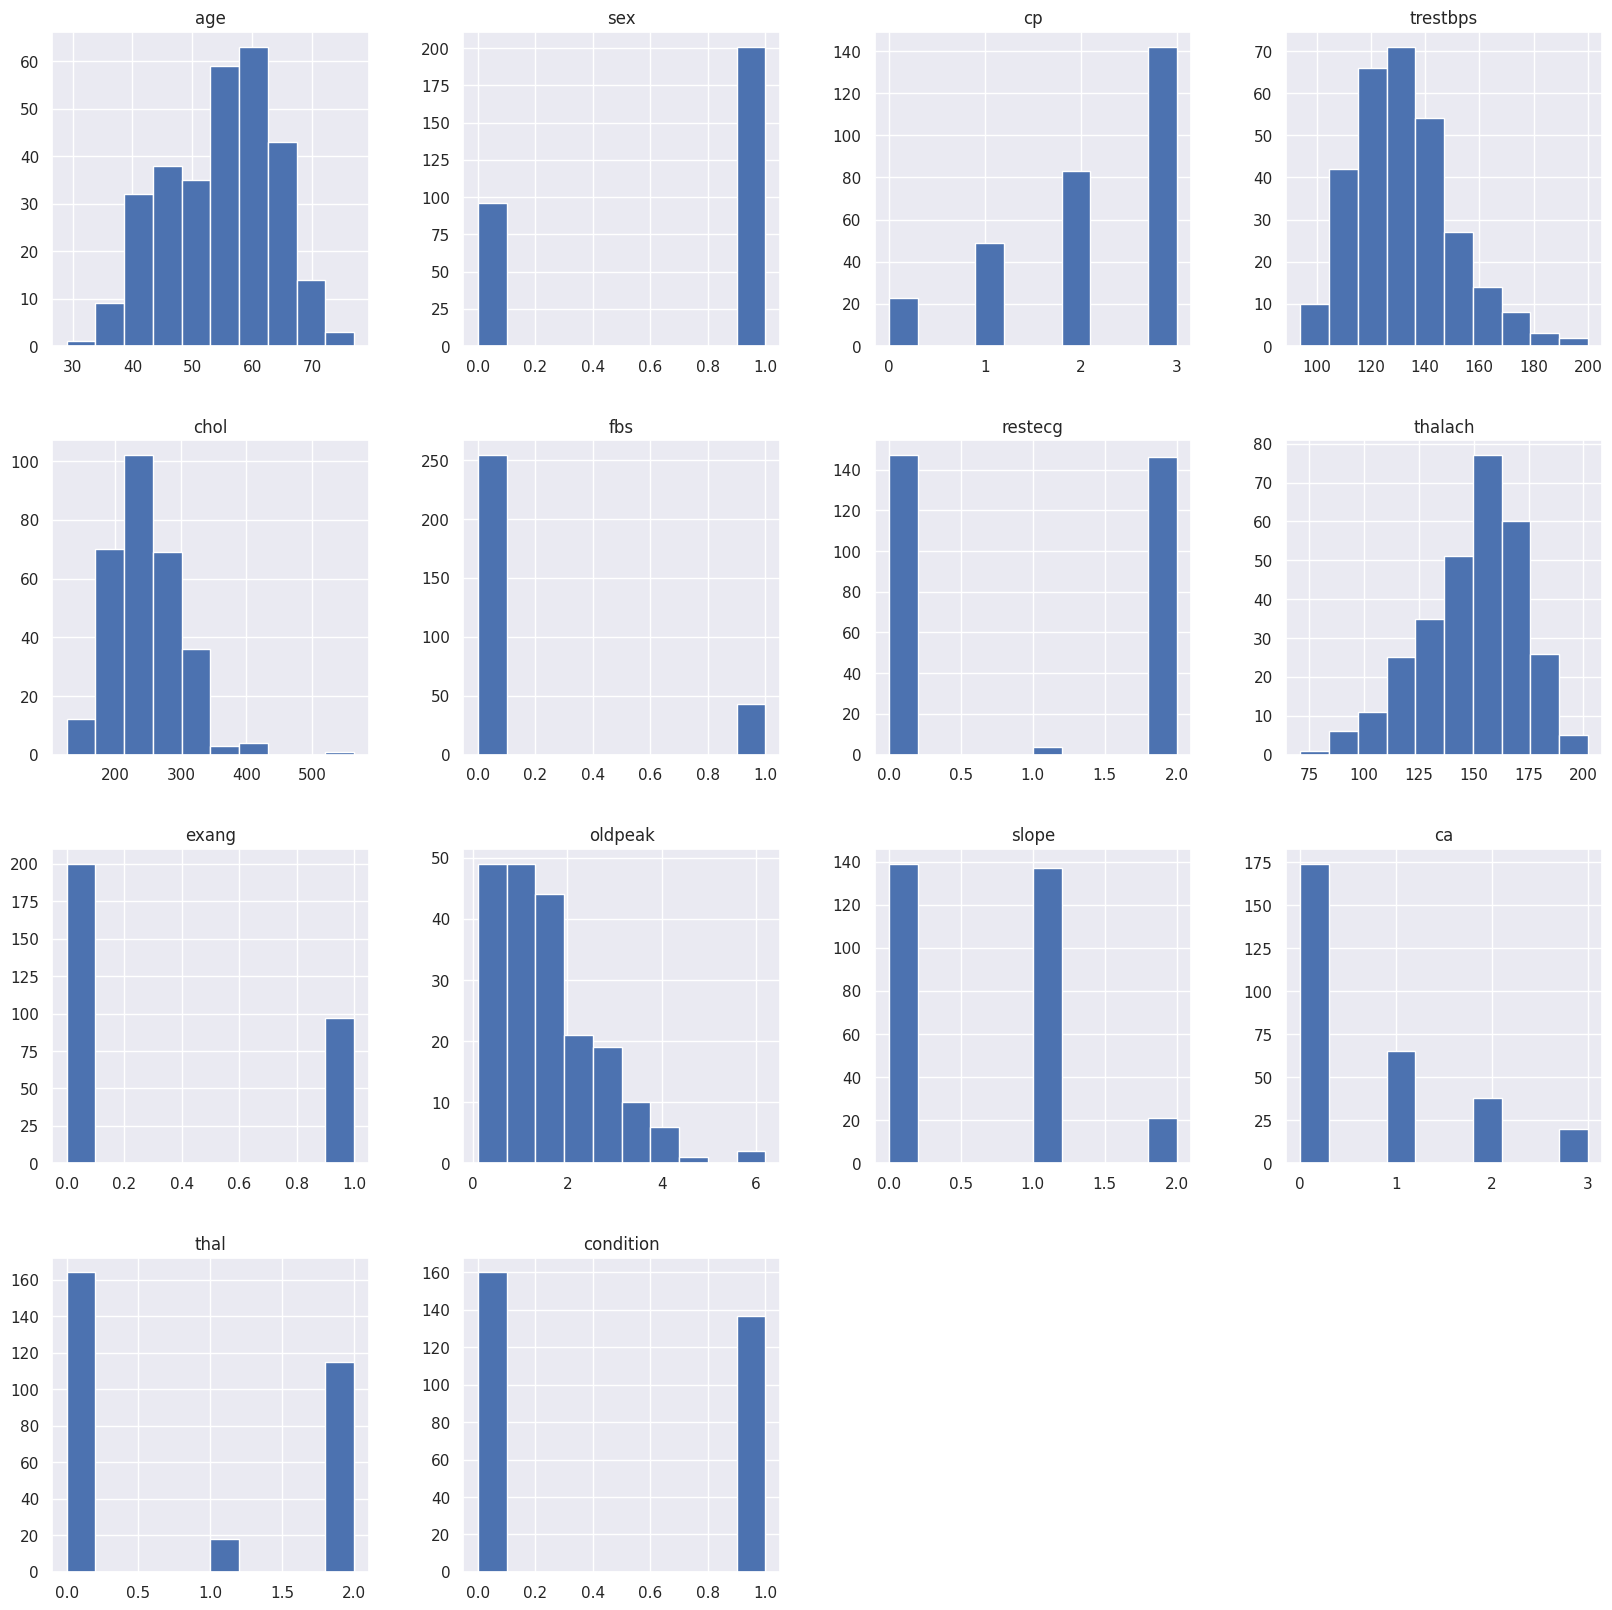

In [10]:
p = heart_data_copy.hist(figsize=(20, 20))

In [11]:
# Use mean values to fill null or nan values
heart_data_copy['trestbps'].fillna(heart_data_copy['trestbps'].mean(),
                                    inplace=True)
heart_data_copy.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,96


In [12]:
# Use mean values to fill null or nan values
heart_data_copy['chol'].fillna(heart_data_copy['chol'].mean(),
                                inplace=True)
heart_data_copy.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,96


In [13]:
# Use median values to fill null or nan values
heart_data_copy['thalach'].fillna(heart_data_copy['thalach'].median(),
                                   inplace=True)
heart_data_copy.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,96


In [14]:
# Use median values to fill null or nan values
heart_data_copy['oldpeak'].fillna(heart_data_copy['oldpeak'].median(),
                                   inplace=True)
heart_data_copy.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


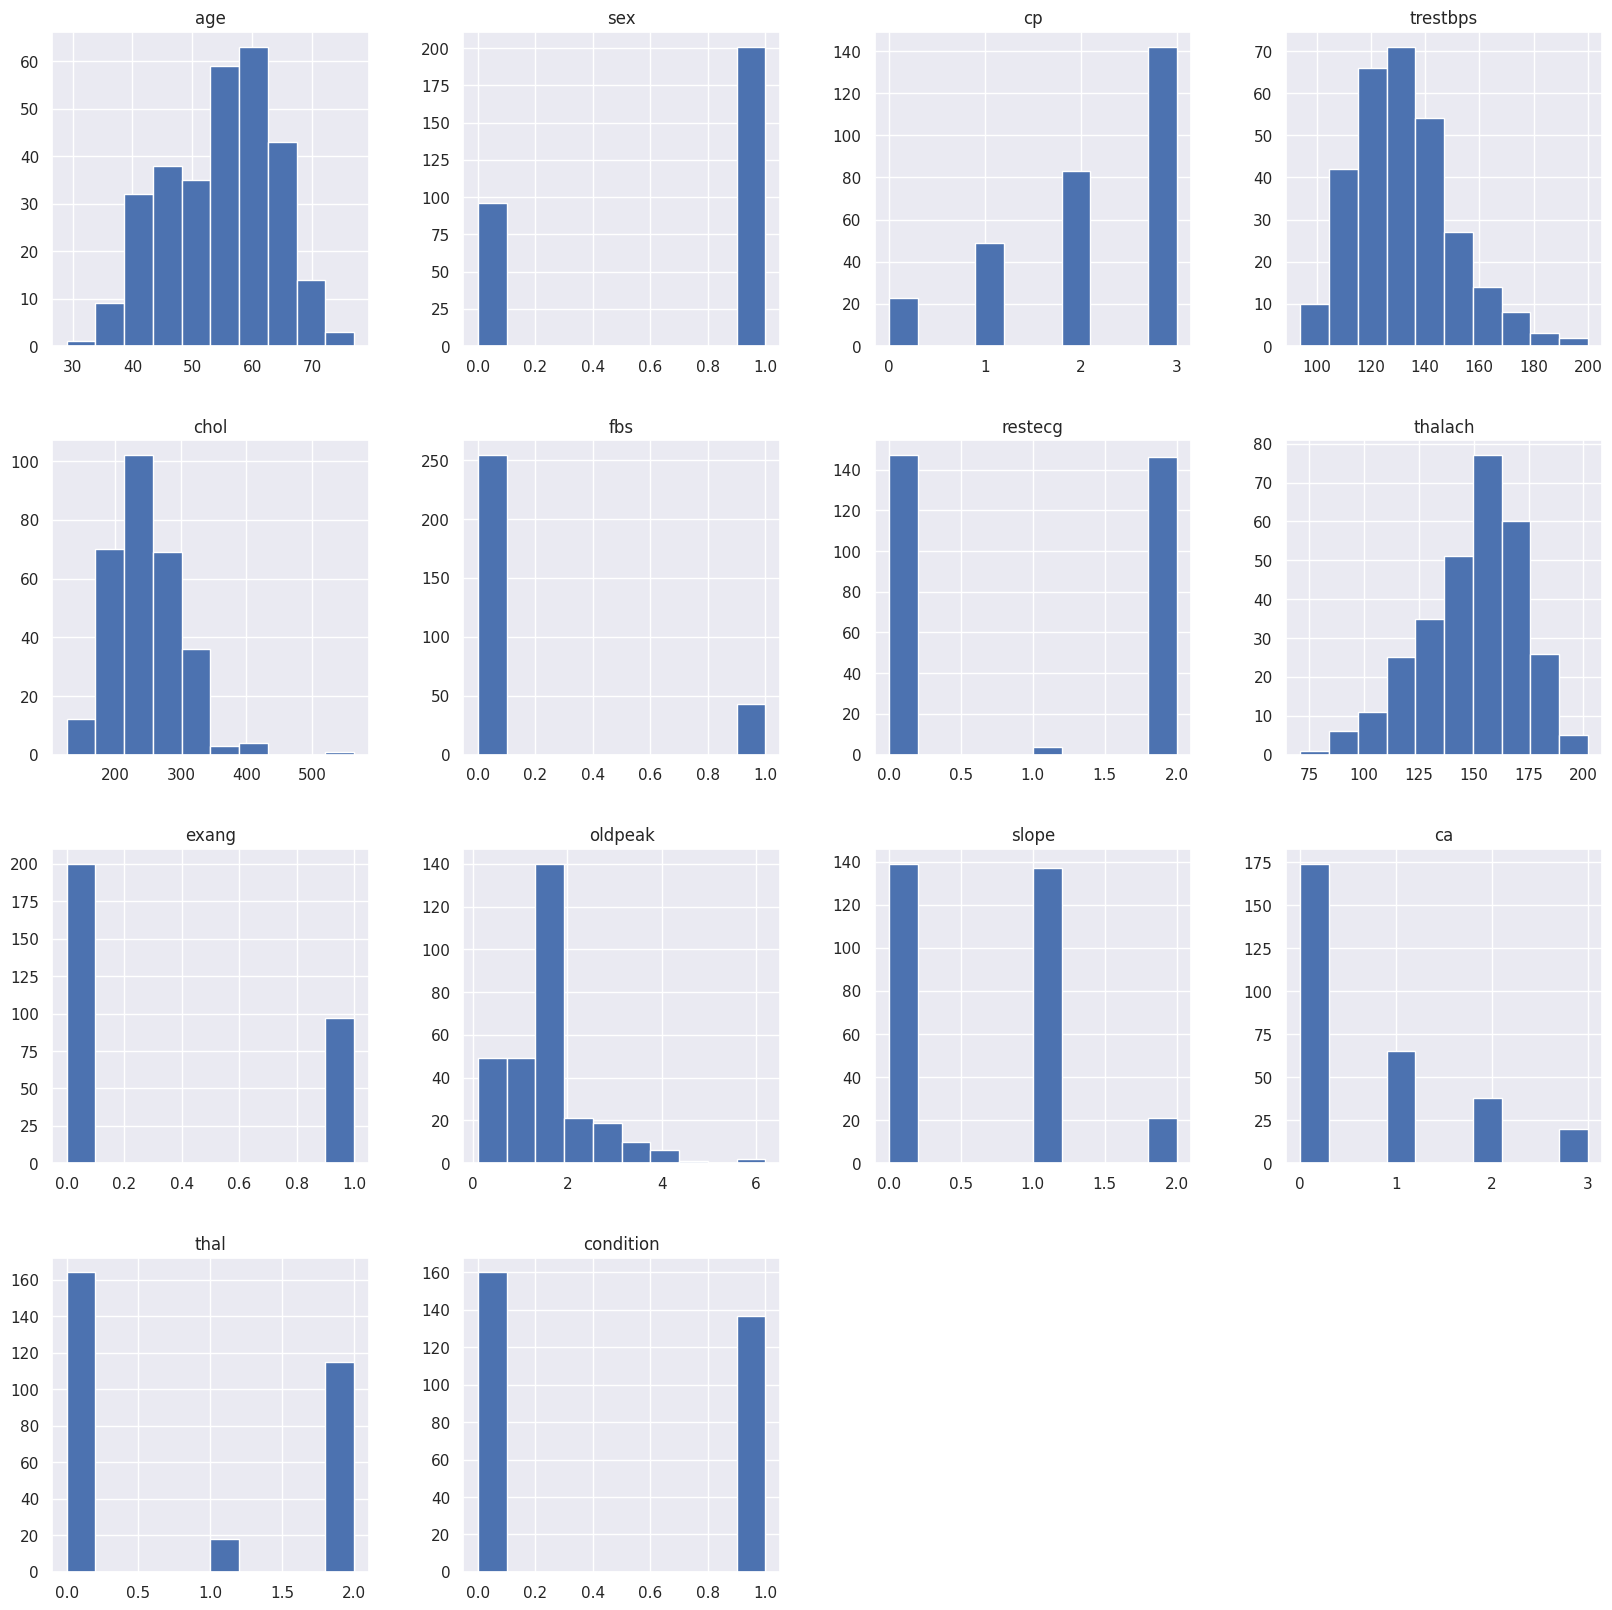

In [15]:
#Data Distribution Plot after NaN removal
p = heart_data_copy.hist(figsize=(20, 20))

In [16]:
## observing the shape of the data
heart_data.shape

(297, 14)

In [17]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


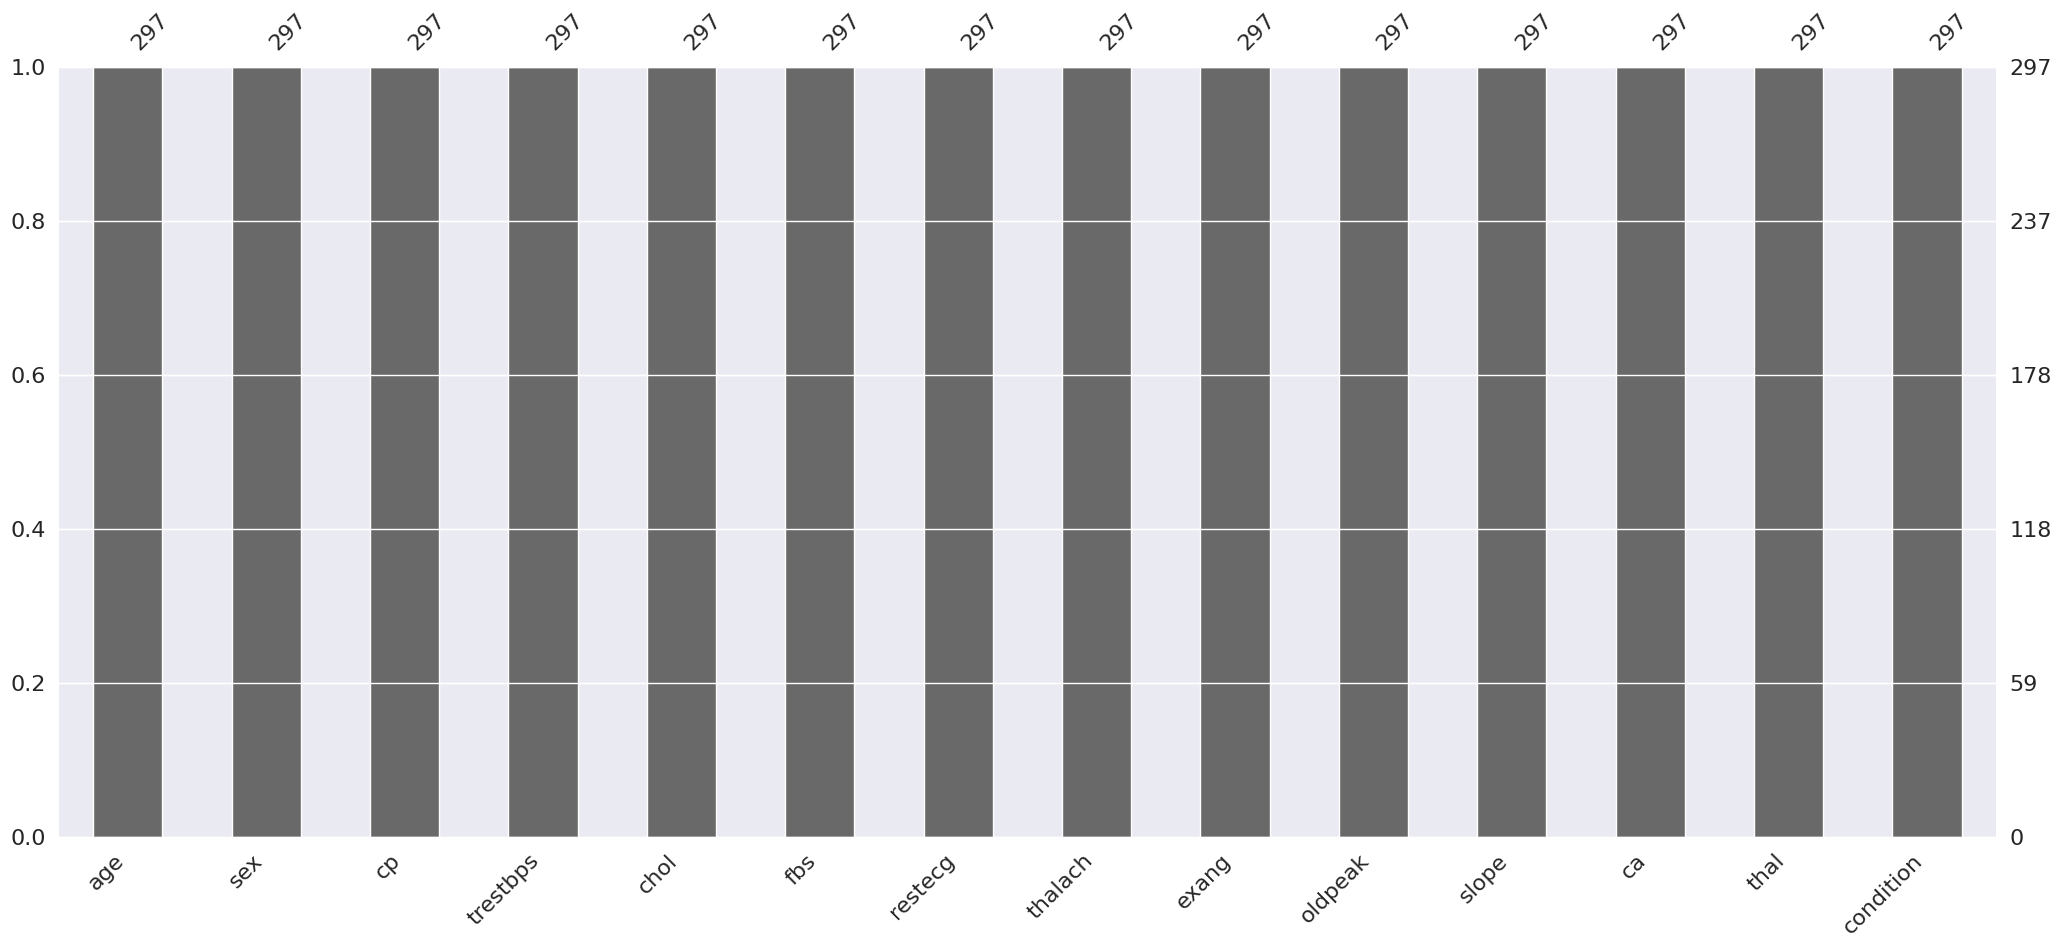

In [18]:
## null count analysis
import missingno as msno
p = msno.bar(heart_data)

condition
0    160
1    137
Name: count, dtype: int64


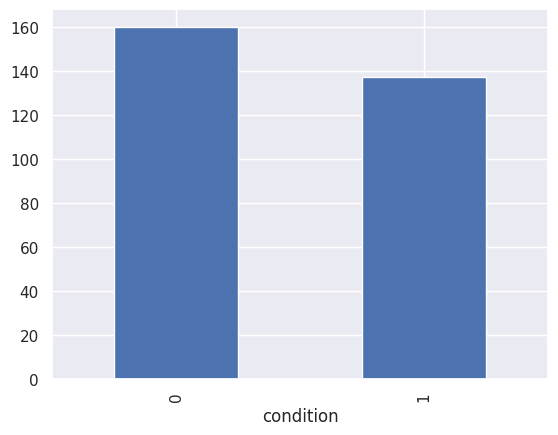

In [19]:
## checking the balance of the data by plotting the count of
## condition by their value
color_wheel = {1: "#0392cf",
               2: "#7bc043"}
colors = heart_data["condition"].map(lambda x: color_wheel.get(x + 1))
print(heart_data.condition.value_counts())
p = heart_data.condition.value_counts().plot(kind="bar")

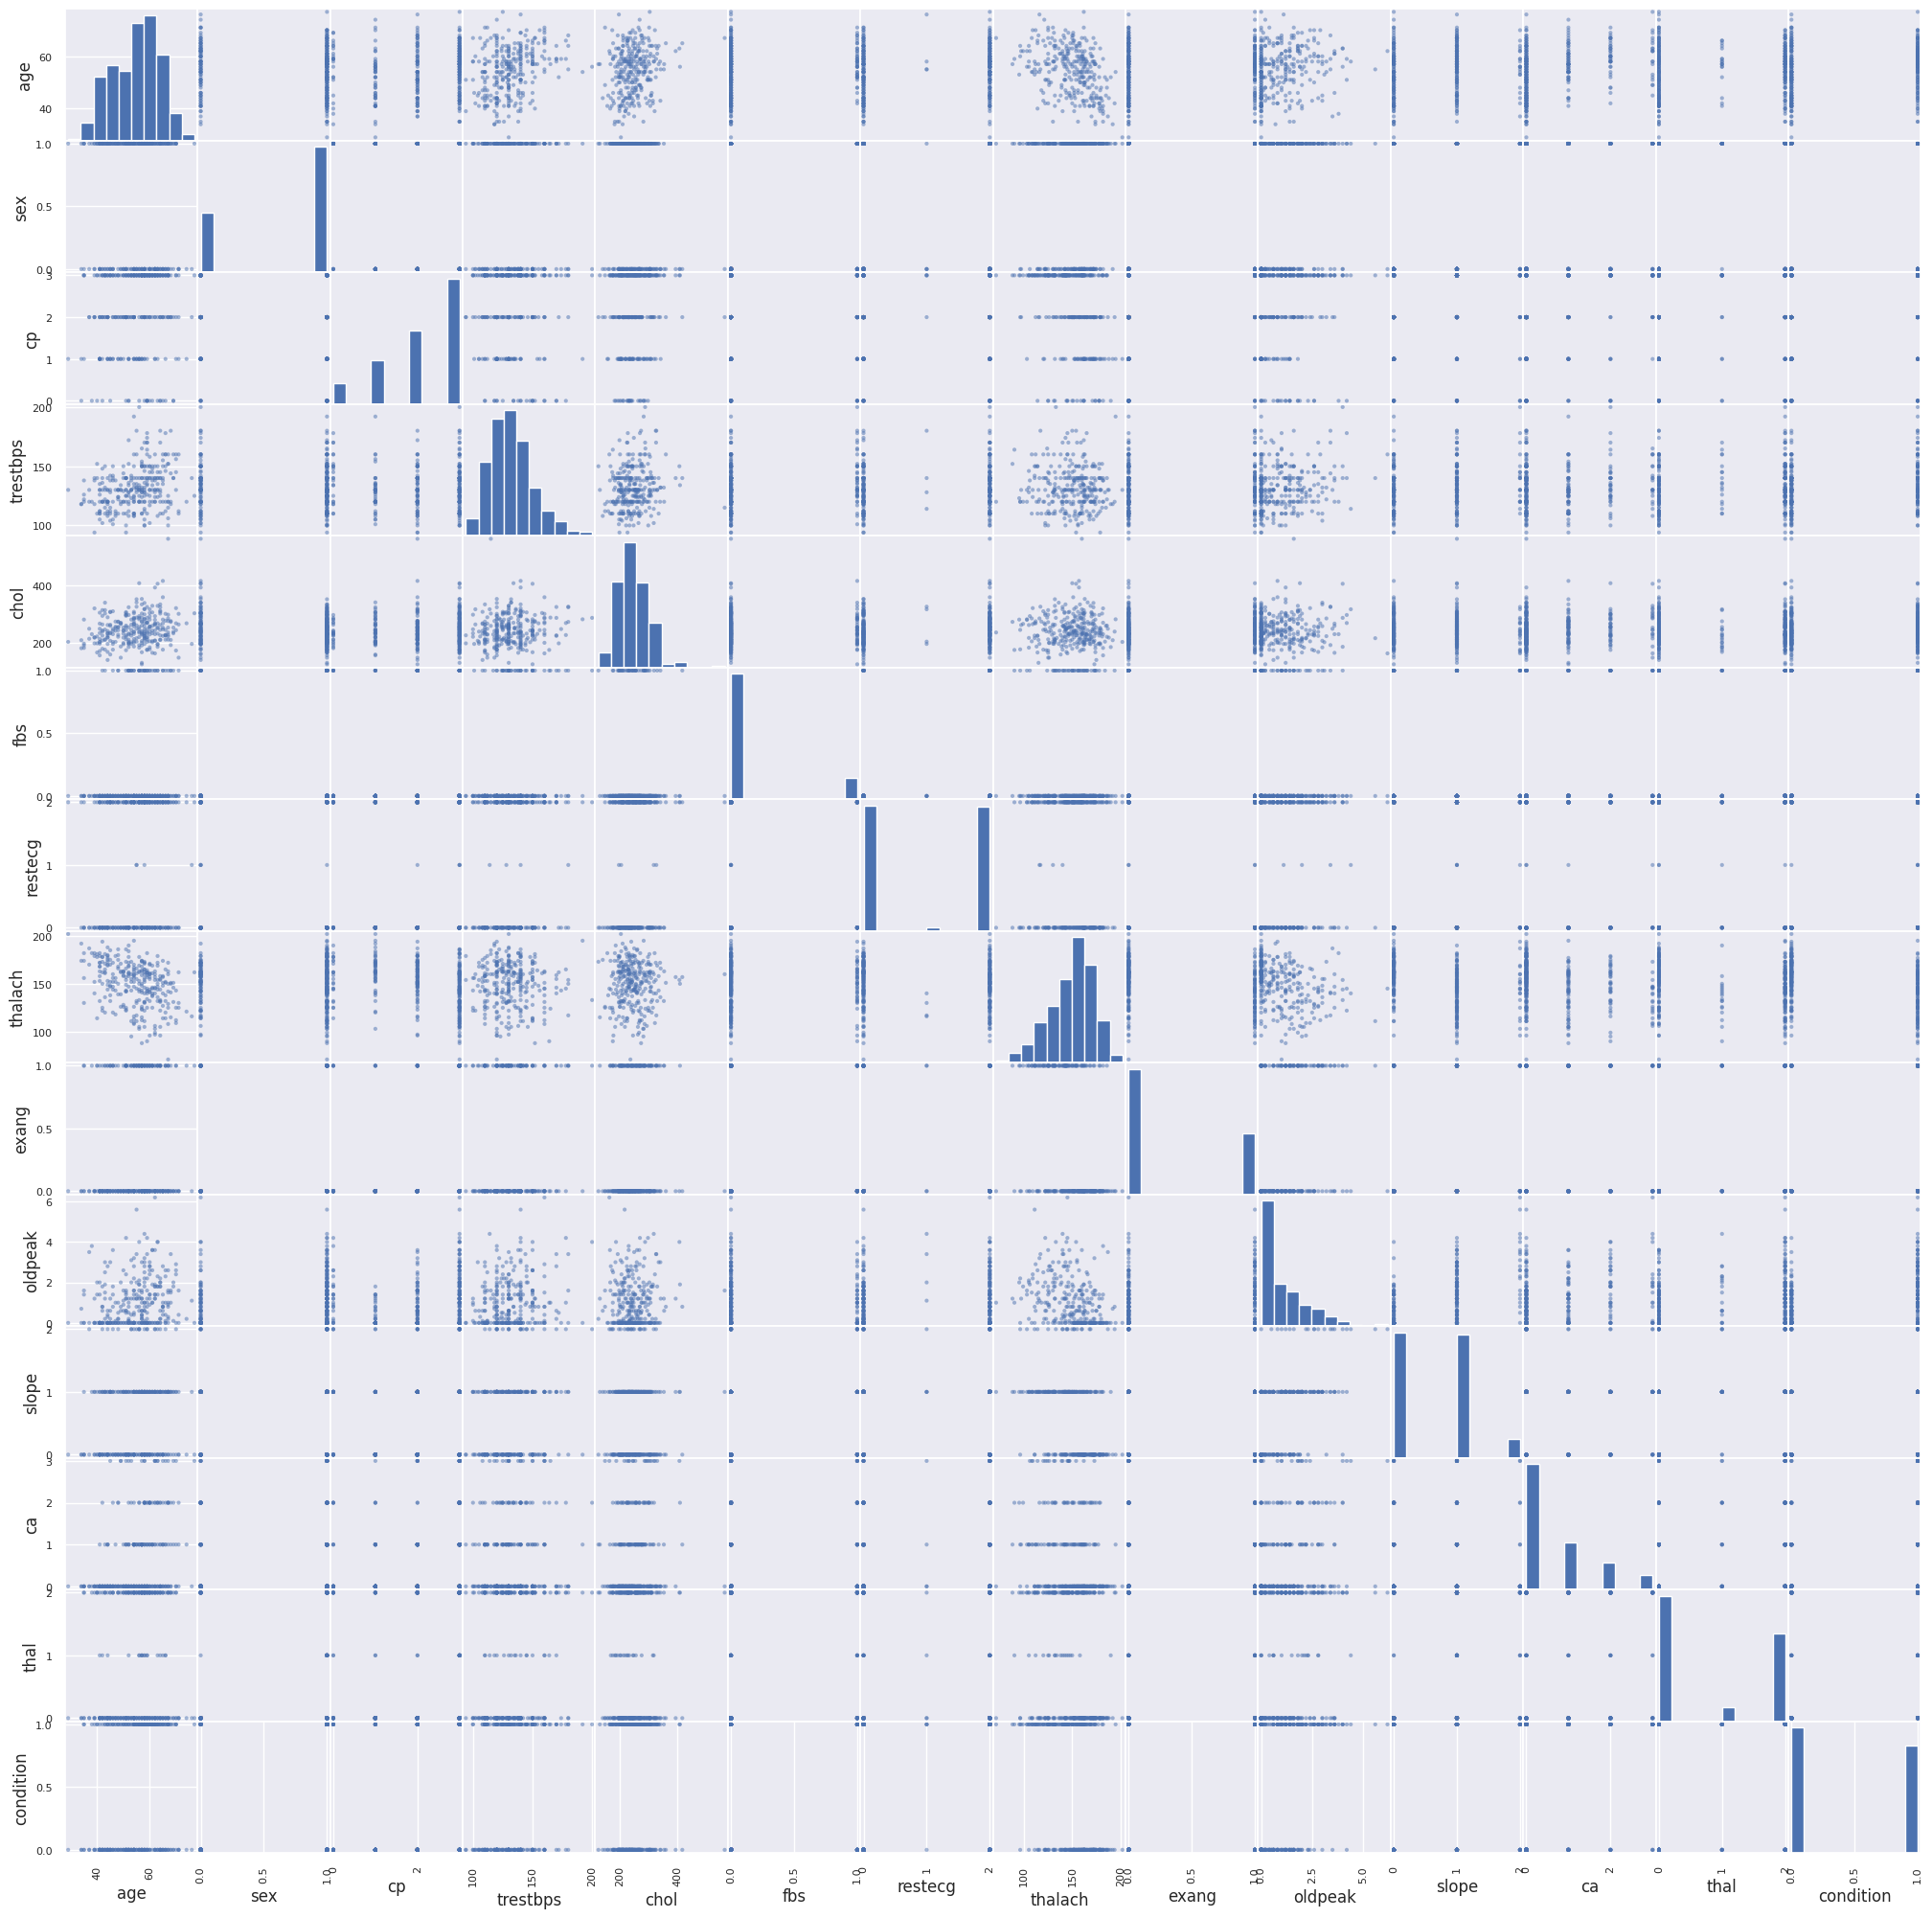

In [20]:
#Scatter matrix of uncleaned data

from pandas.plotting import scatter_matrix
p = scatter_matrix(heart_data, figsize=(25, 25))

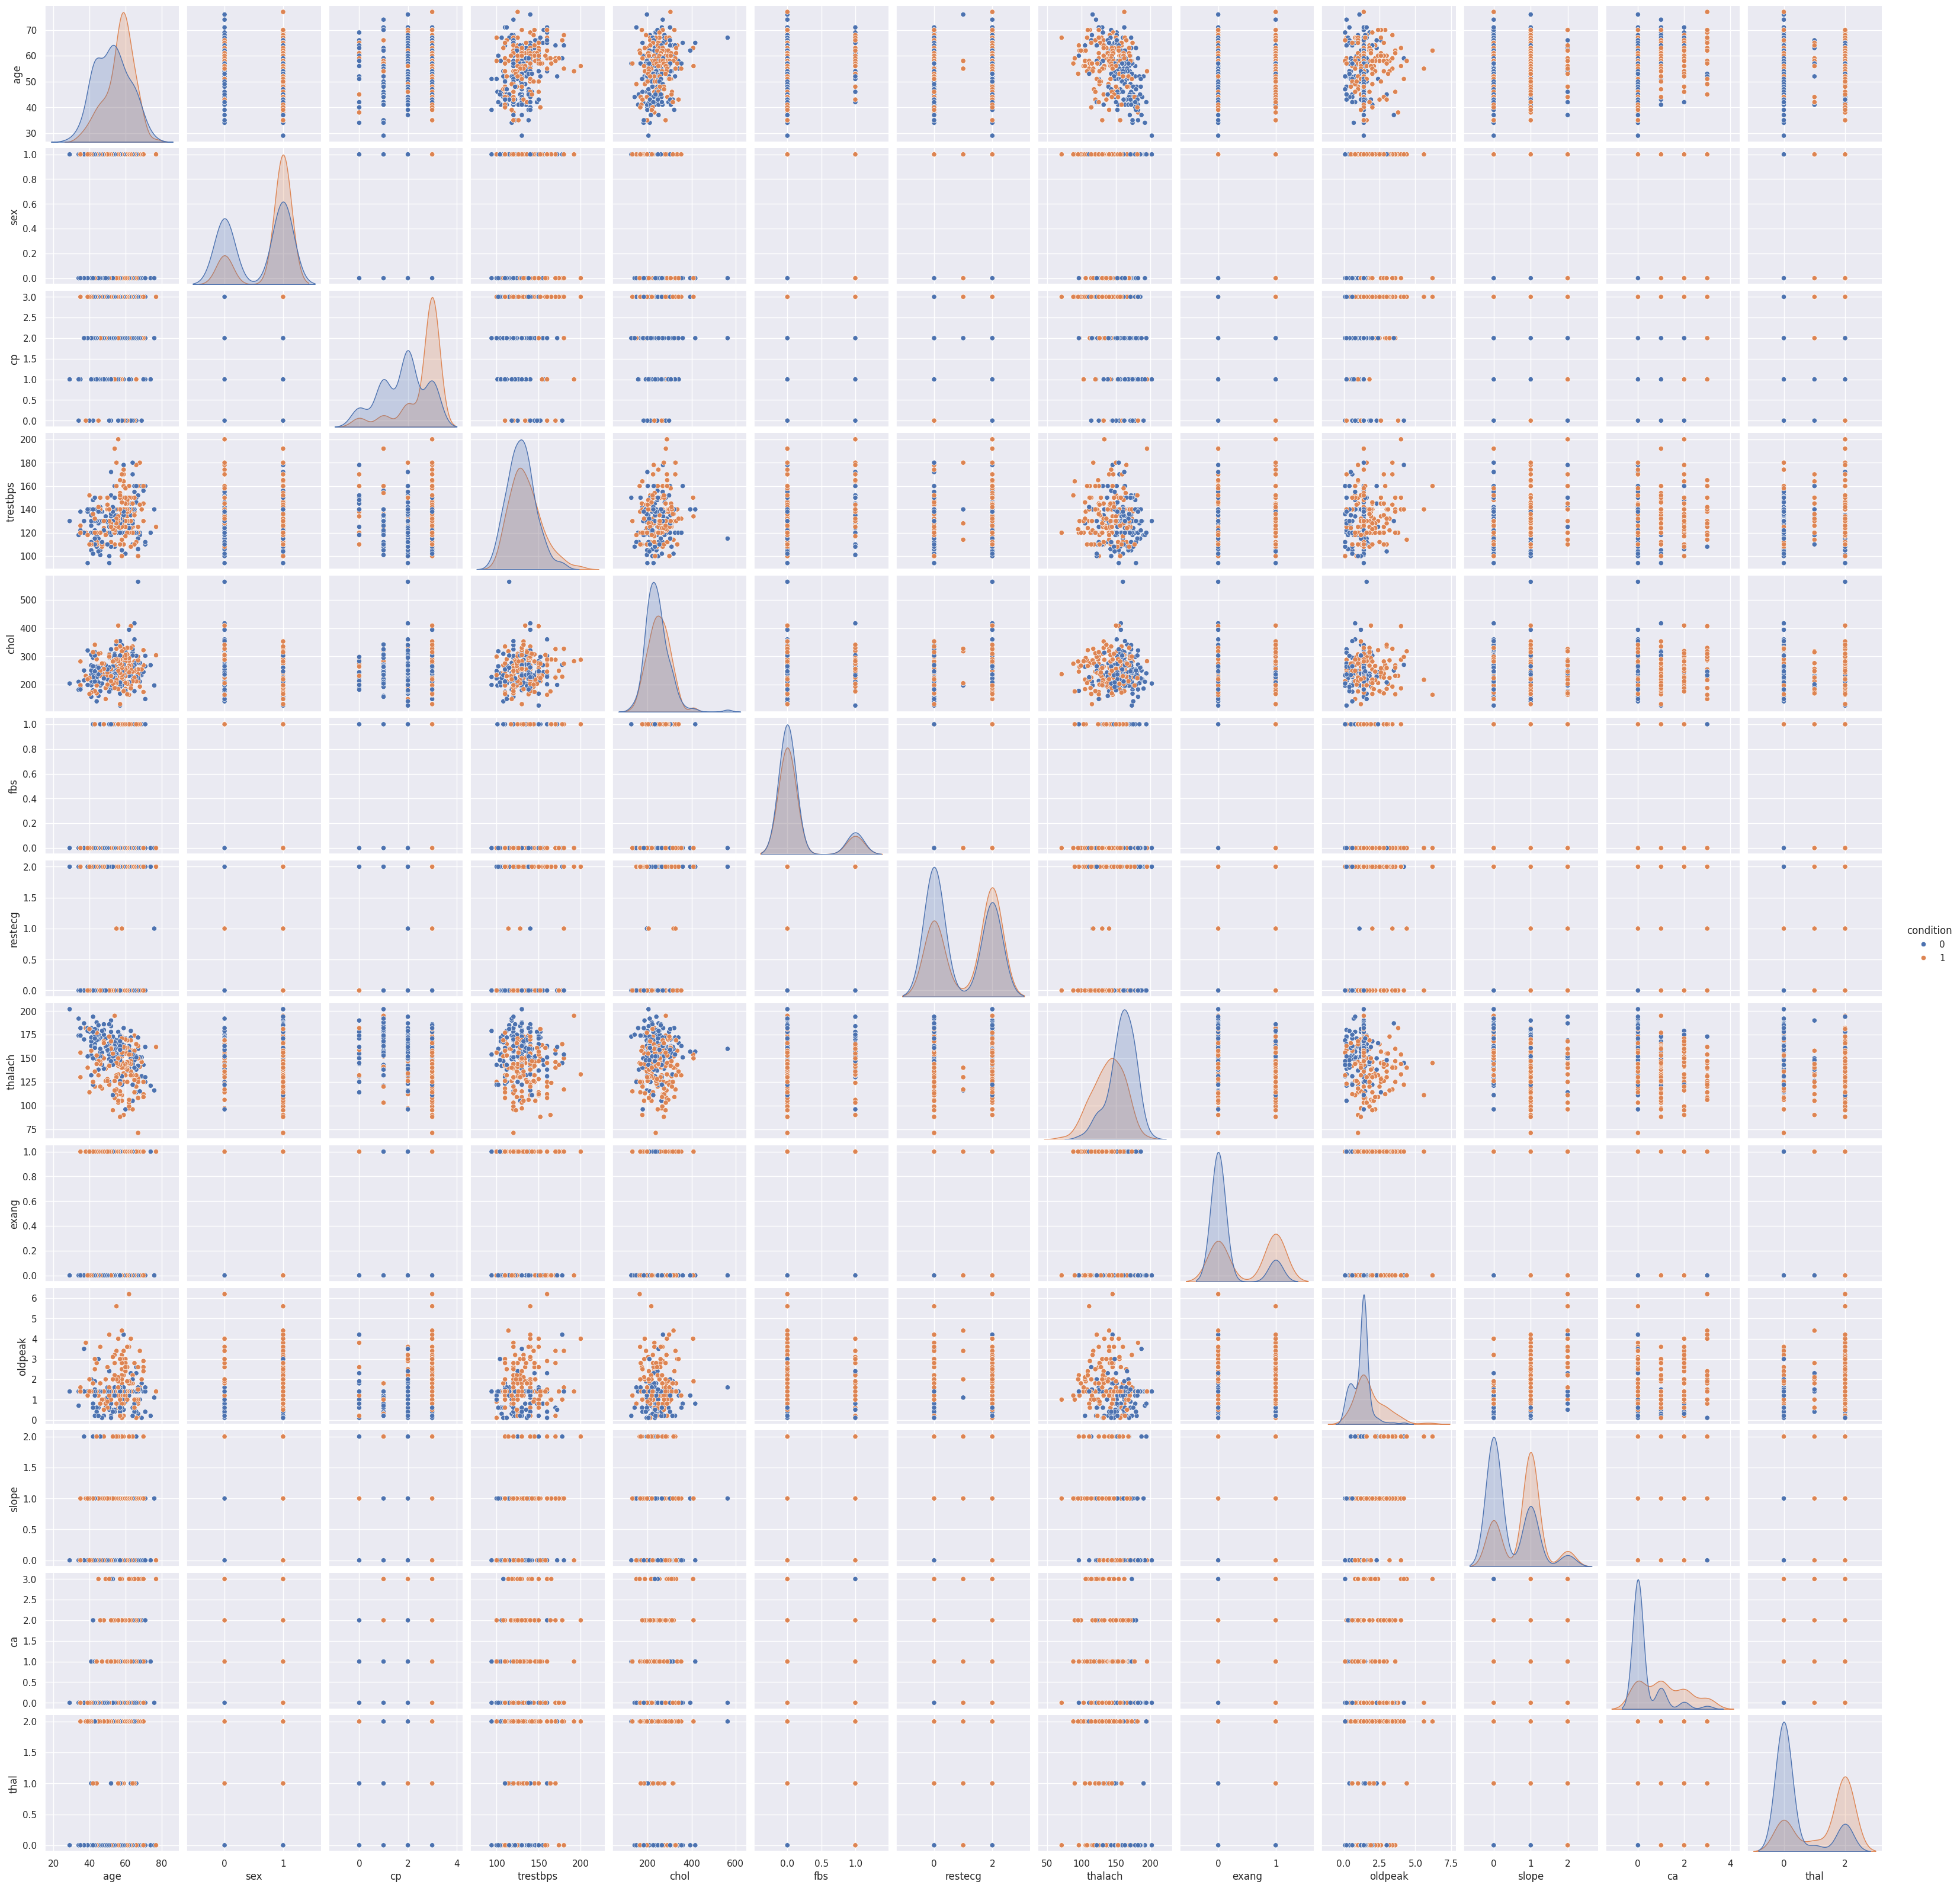

In [21]:
#Pair plot for clean data
p = sns.pairplot(heart_data_copy, hue='condition')

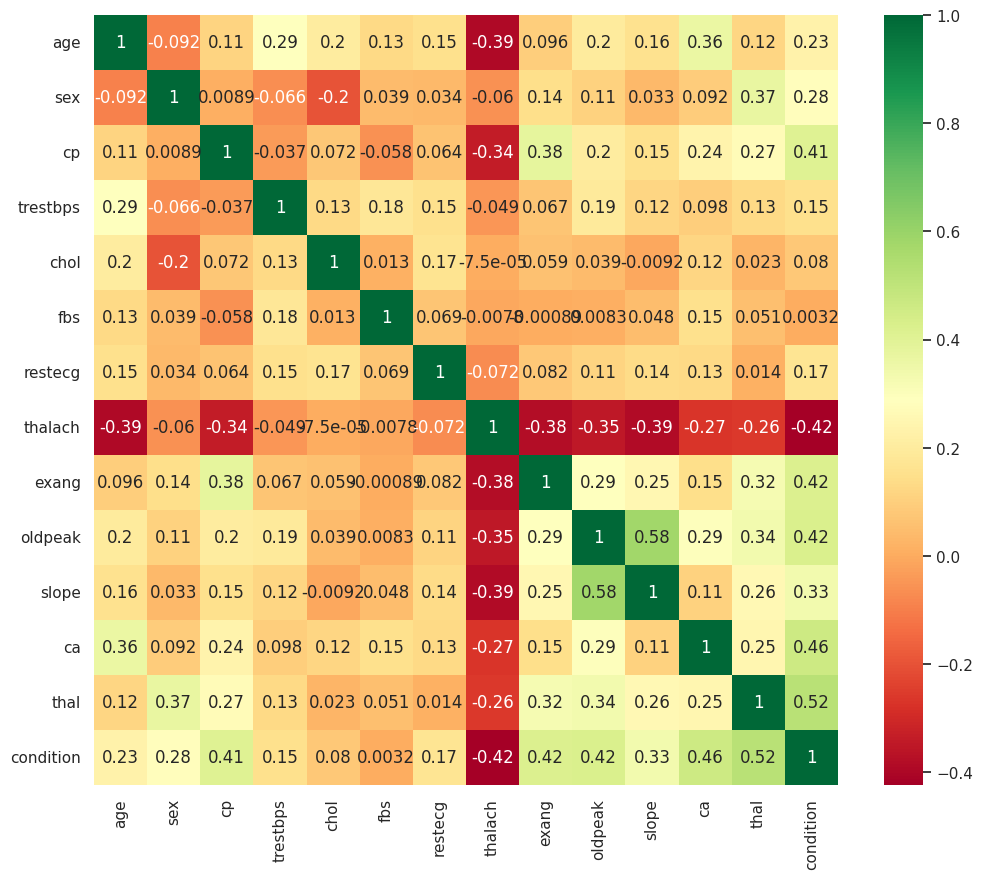

In [22]:
#Heatmap for unclean data

plt.figure(figsize=(12, 10))
p = sns.heatmap(heart_data.corr(), annot=True, cmap='RdYlGn')

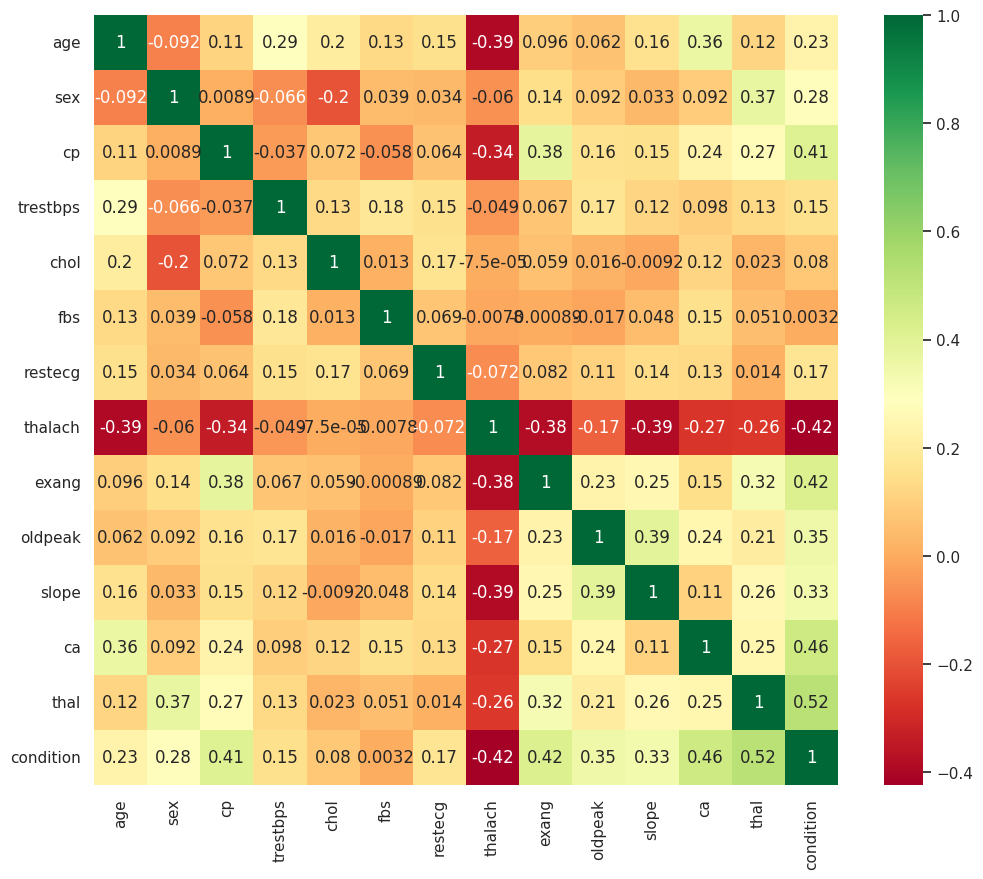

In [23]:
#Heatmap for clean data

plt.figure(figsize=(12, 10))
p = sns.heatmap(heart_data_copy.corr(), annot=True, cmap='RdYlGn')

In [24]:
# dataframe before transformation
heart_data_copy.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


## Scaling the data

In [25]:
# scaling the data
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X = pd.DataFrame(sc_X.fit_transform(heart_data_copy.drop(["condition"], axis=1)),
                 columns=['age', 'sex', 'cp', 'trestbps', 'chol',
                          'fbs', 'restecg', 'thalach', 'exang',
                          'oldpeak', 'slope', 'ca', 'thal'])

X.head()  # looking at the transformed data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,1.600302,0.691095,-2.240629,1.596266,-0.257179,2.430427,1.010199,-0.812095,-0.696419,-1.546792,0.643781,0.344824,-0.874292
1,1.600302,-1.446980,-2.240629,0.468418,-0.160859,-0.411450,-1.003419,0.061157,-0.696419,0.320676,-0.976583,1.411625,-0.874292
2,1.268242,-1.446980,-2.240629,1.032342,-0.411292,-0.411450,-1.003419,-1.554358,-0.696419,1.199485,2.264145,-0.721976,-0.874292
3,1.157555,0.691095,-2.240629,0.355633,0.667499,2.430427,1.010199,1.065396,-0.696419,-0.118728,0.643781,0.344824,-0.874292
4,1.046868,0.691095,-2.240629,-1.223355,-0.700254,-0.411450,1.010199,-0.244481,1.435916,0.320676,0.643781,-0.721976,-0.874292


In [28]:
y = heart_data_copy.condition  # assigning the label column

# importing train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=1/3,
                                                      random_state=42,
                                                      stratify=y)

## Result Visualisation for KNN

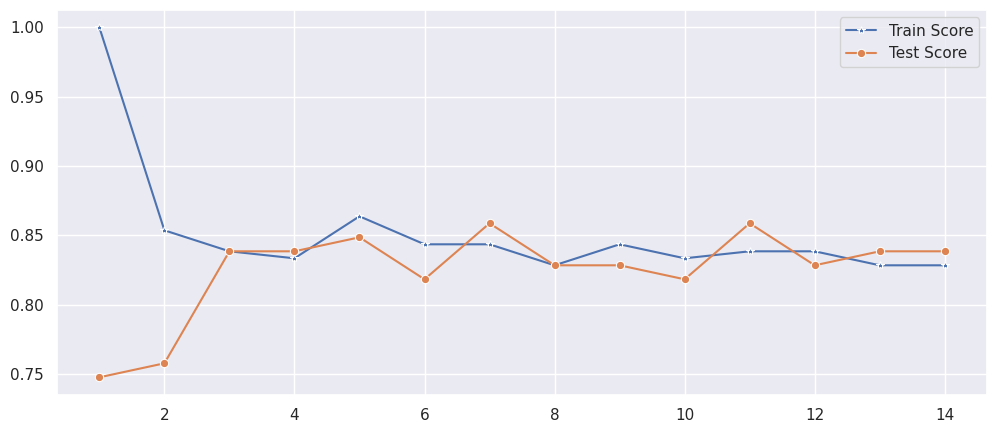

In [29]:
## finding best k value
from sklearn.neighbors import KNeighborsClassifier

train_scores = []
test_scores = []

for k in range(1, 15):
    knn = KNeighborsClassifier(k)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))

plt.figure(figsize=(12, 5))
p = sns.lineplot(x=range(1, 15), y=train_scores, marker='*',
                 label='Train Score')
p = sns.lineplot(x=range(1, 15), y=test_scores, marker='o',
                 label='Test Score')

## Model Training - KNN

In [30]:
# Setup a knn classifier with k neighbors
knn = KNeighborsClassifier(11)

knn.fit(X_train, y_train)
knn.score(X_test, y_test)

0.8585858585858586

## Model Performance Analysis

In [31]:
# import confusion_matrix
from sklearn.metrics import confusion_matrix
# let us get the predictions using the classifier we had fit above
y_pred = knn.predict(X_test)
y_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0])

In [32]:
confusion_matrix(y_test, y_pred)
pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'],
            margins=True)

Predicted,0,1,All
True,,,
0,50,3,53
1,11,35,46
All,61,38,99


Text(0.5, 19.049999999999997, 'Predicted label')

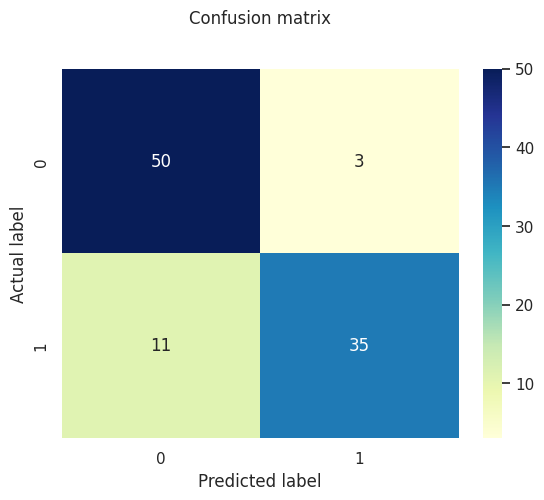

In [33]:
# Creating a Heatmap for the confusion matrix
y_pred = knn.predict(X_test)
from sklearn import metrics
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
p = sns.heatmap(pd.DataFrame(cnf_matrix), annot=True,
                cmap="YlGnBu", fmt='g')
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [34]:
# import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.94      0.88        53
           1       0.92      0.76      0.83        46

    accuracy                           0.86        99
   macro avg       0.87      0.85      0.86        99
weighted avg       0.87      0.86      0.86        99



In [35]:
from sklearn.metrics import roc_curve
y_pred_proba = knn.predict_proba(X_test)[:, 1]
y_pred_proba

array([0.        , 0.09090909, 0.36363636, 0.90909091, 0.27272727,
       0.72727273, 0.18181818, 0.27272727, 0.72727273, 0.54545455,
       0.09090909, 0.54545455, 0.72727273, 1.        , 0.18181818,
       1.        , 0.18181818, 0.09090909, 0.18181818, 0.81818182,
       0.63636364, 0.18181818, 0.63636364, 0.63636364, 0.18181818,
       1.        , 0.36363636, 0.81818182, 0.09090909, 0.        ,
       0.81818182, 0.72727273, 0.27272727, 0.81818182, 0.90909091,
       0.18181818, 0.        , 0.18181818, 0.18181818, 0.36363636,
       0.45454545, 0.        , 0.        , 0.90909091, 0.        ,
       0.09090909, 0.90909091, 1.        , 0.90909091, 0.27272727,
       0.        , 0.81818182, 0.09090909, 0.09090909, 0.81818182,
       0.09090909, 0.72727273, 0.27272727, 0.54545455, 0.27272727,
       0.36363636, 0.36363636, 0.09090909, 0.36363636, 0.72727273,
       0.18181818, 0.09090909, 0.09090909, 0.81818182, 1.        ,
       0.72727273, 0.36363636, 0.18181818, 0.90909091, 0.18181

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
print('FPR')
print(fpr)
print('TPR')
print(tpr)
print('Thresholds')
print(thresholds)

FPR
[0.         0.         0.         0.         0.01886792 0.05660377
 0.05660377 0.0754717  0.1509434  0.26415094 0.56603774 0.81132075
 1.        ]
TPR
[0.         0.10869565 0.23913043 0.45652174 0.65217391 0.67391304
 0.76086957 0.7826087  0.89130435 0.93478261 0.95652174 1.
 1.        ]
Thresholds
[       inf 1.         0.90909091 0.81818182 0.72727273 0.63636364
 0.54545455 0.45454545 0.36363636 0.27272727 0.18181818 0.09090909
 0.        ]


## Plotting the ROC Curve

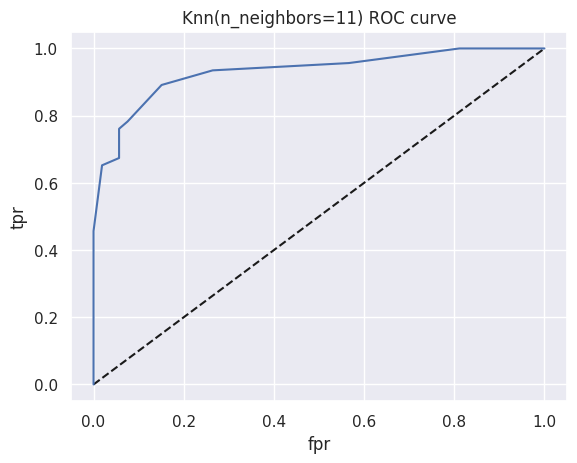

In [37]:
# Plotting the ROC Curve
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr, tpr, label='Knn')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('Knn(n_neighbors=11) ROC curve')
plt.show()

## Area under ROC curve

In [38]:
# Area under ROC curve
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, y_pred_proba)

np.float64(0.9306808859721083)

In [39]:
# import GridSearchCV
from sklearn.model_selection import GridSearchCV
# In case of classifier like knn the parameter to be tuned is n_neighbors
param_grid = {'n_neighbors': np.arange(1, 50)}
knn = KNeighborsClassifier()
knn_cv = GridSearchCV(knn, param_grid, cv=5)
knn_cv.fit(X, y)

print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score:0.8285310734463277
Best Parameters: {'n_neighbors': np.int64(21)}
